# Introduction

## Post

If you pay enough attention to a fern, you’ll notice a pattern: each frond resembles a branch, which resembles a leaflet. The largest leaf is similar to the smallest one. Its structure appears to be infinitely complex, but it can be made surprisingly simple with the mathematics of self-similarity.

The pictured Barnsley fern is generated by a technique known as an iterated function system (IFS), which creates fractal patterns by repeatedly applying simple affine maps—linear transformations plus shifts—at random with fixed probabilities.

British mathematician Michael Barnsley used only four such transformations. Start with any point in the plane. At each step, pick one of the four maps, apply it to the current point, and plot the result. After tens of thousands of steps, a fern appears.

The first map is a vertical scaling that draws the stem, the other three shrink, rotate, and translate points to form the leaflets. The probabilities control how often each feature is sampled, tuning the point density so the fronds look full while the stem stays thin. Despite the randomness, the system converges to a stable geometric set—the attractor—because the maps act (roughly) as contractions.

You can play with the number of maps and their coefficients and probabilities to generate more breathtaking images - all with a handful of simple transformations.

By the way, the inverse problem of finding an algorithm that identifies a set of IFS maps from an arbitrary image is far from trivial. Arnaud Jacquin proposed a practical method for specific cases, while the general problem remains unsolved. Jacquin’s approach is used in fractal compression software.

Here’s the **mathematical context** for the Barnsley Fern written in clean Markdown (with LaTeX math syntax, ready to paste into your notebook, README, or article):

---

## Mathematical Context — Barnsley Fern

The **Barnsley Fern** is a classic example of a *fractal generated by an Iterated Function System (IFS)*.
It uses a set of affine transformations applied probabilistically to produce a self-similar structure resembling a natural fern.

The system consists of four affine transformations:

$$
\begin{pmatrix}
x' \\[3pt]
y'
\end{pmatrix}
=
\begin{pmatrix}
a_i & b_i \\[3pt]
c_i & d_i
\end{pmatrix}
\begin{pmatrix}
x \\[3pt]
y
\end{pmatrix}
+
\begin{pmatrix}
e_i \\[3pt]
f_i
\end{pmatrix},
\quad i \in \{1,2,3,4\}.
$$


Each transformation corresponds to a different part of the fern. At each iteration, one transformation is chosen at random according to its probability $p_i$, and applied to the current point $(x, y)$. The process is repeated recursively, and the resulting set of points converges to a fractal attractor.


## References
* https://www.linkedin.com/posts/vzabrodskiy_if-you-pay-enough-attention-to-a-fern-you-activity-7392860166599221248-uKVH?utm_source=share&utm_medium=member_desktop&rcm=ACoAAAYVLuwBRoOGLctydlL6oZP7Ffwirgxbs9Q
* M. F. Barnsley, *Fractals Everywhere*, Academic Press, 1988.
* H. Peitgen, H. Jürgens, D. Saupe, *Chaos and Fractals: New Frontiers of Science*, Springer, 1992.
* https://en.wikipedia.org/wiki/Barnsley_fern

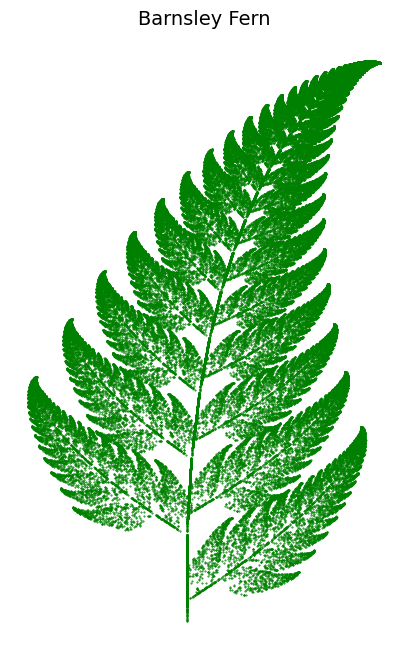

In [1]:
import matplotlib.pyplot as plt
from random import random
from bisect import bisect

PROB = (0.01, 0.86, 0.93, 1.00)  # cumulative probabilities
MAPS = (
    (0.00,  0.00,  0.00, 0.16, 0.00, 0.00),  # stem
    (0.85,  0.04, -0.04, 0.85, 0.00, 1.60),  # main leaf
    (0.20, -0.26,  0.23, 0.22, 0.00, 1.60),  # left leaf
    (-0.15, 0.28,  0.26, 0.24, 0.00, 0.44),  # right leaf
)

def transform(x: float, y: float):
    a, b, c, d, e, f = MAPS[bisect(PROB, random())]
    return a*x + b*y + e, c*x + d*y + f

# --- Generate fern points ---
n = 100_000
x, y = 0.0, 0.0
xs, ys = [], []
for _ in range(n):
    x, y = transform(x, y)
    xs.append(x)
    ys.append(y)

# --- Plot ---
plt.figure(figsize=(5, 8))
plt.scatter(xs, ys, s=0.2, color="green")
plt.axis("off")
plt.title("Barnsley Fern", fontsize=14)
plt.show()